In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

matches = pd.read_csv("../data/processed/matches_cleaned.csv")
deliveries = pd.read_excel("../data/raw/deliveries.xlsx")

print("Business Insights Notebook Loaded Successfully!")

Business Insights Notebook Loaded Successfully!


In [2]:
# Teams winning while chasing

chasing = matches[matches["result"] == "wickets"]

best_chasing = (
    chasing["winner"]
    .value_counts()
    .reset_index()
)

best_chasing.columns = ["Team","Successful Chases"]

display(best_chasing)

,Team,Successful Chases
0,Kolkata Knight Riders,76
1,Mumbai Indians,71
2,Rajasthan Royals,67
3,Chennai Super Kings,67
4,Delhi Capitals,66
5,Royal Challengers Bengaluru,64
6,Punjab Kings,58
7,Sunrisers Hyderabad,43
8,Gujarat Titans,17
9,Gujarat Lions,12


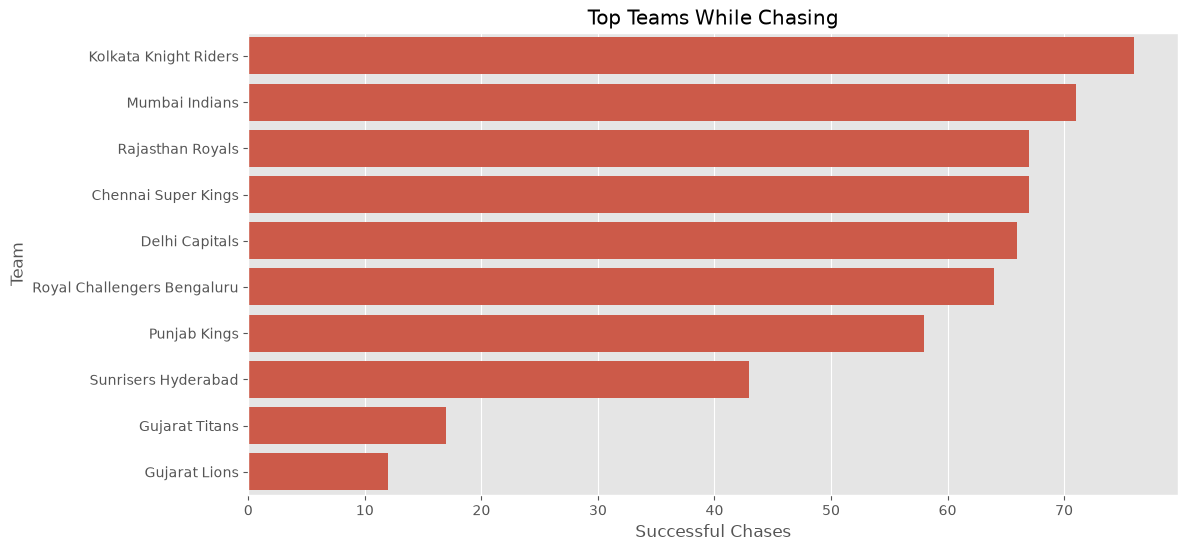

In [3]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=best_chasing.head(10),
    x="Successful Chases",
    y="Team"
)

plt.title("Top Teams While Chasing")

plt.show()

In [4]:
bat_first = matches[matches["result"] == "runs"]

best_batting_first = (
    bat_first["winner"]
    .value_counts()
    .reset_index()
)

best_batting_first.columns = ["Team","Wins Batting First"]

display(best_batting_first)

,Team,Wins Batting First
0,Chennai Super Kings,71
1,Mumbai Indians,71
2,Royal Challengers Bengaluru,57
3,Kolkata Knight Riders,54
4,Punjab Kings,51
5,Delhi Capitals,46
6,Sunrisers Hyderabad,44
7,Rajasthan Royals,43
8,Deccan Chargers,18
9,Lucknow Super Giants,16


In [5]:
mvp = (
    matches["player_of_match"]
    .value_counts()
    .head(20)
    .reset_index()
)

mvp.columns=["Player","Awards"]

display(mvp)

,Player,Awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18
5,MS Dhoni,17
6,SR Watson,16
7,YK Pathan,16
8,RA Jadeja,16
9,SP Narine,15


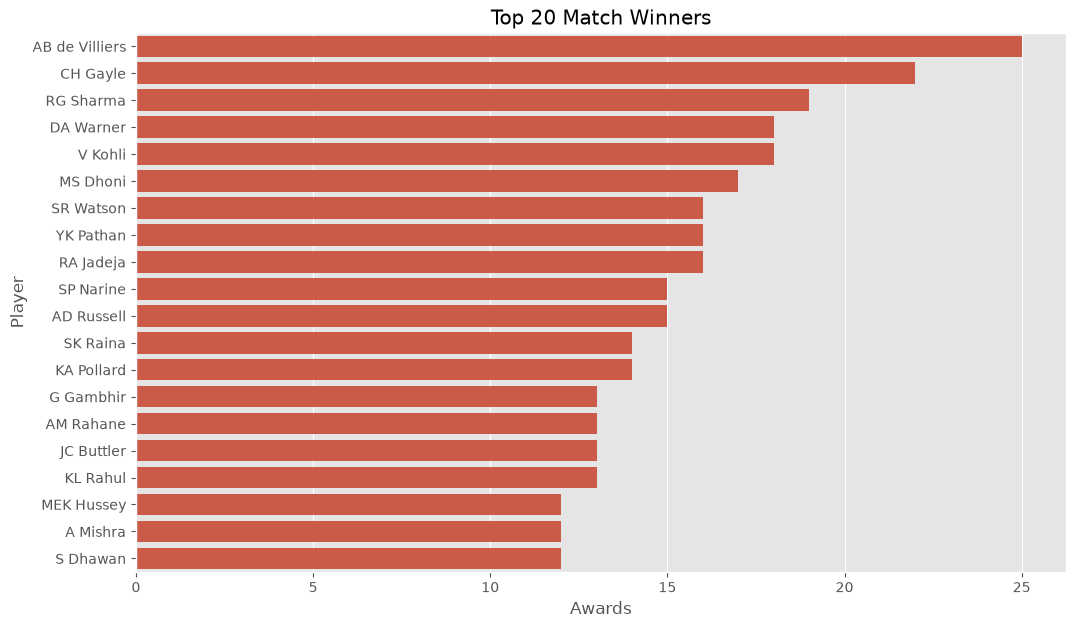

In [6]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=mvp,
    x="Awards",
    y="Player"
)

plt.title("Top 20 Match Winners")

plt.show()

In [7]:
toss = (
    matches["toss_decision"]
    .value_counts()
    .reset_index()
)

toss.columns=["Decision","Count"]

display(toss)

,Decision,Count
0,field,704
1,bat,391


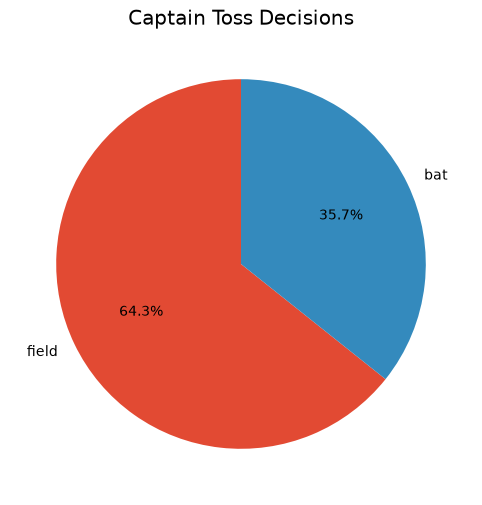

In [8]:
plt.pie(
    toss["Count"],
    labels=toss["Decision"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Captain Toss Decisions")

plt.show()

In [14]:
# =====================================================
# HIGHEST SCORING VENUES
# =====================================================

# Total runs scored in each match
match_runs = (
    deliveries.groupby("match_id")["total_runs"]
    .sum()
    .reset_index()
)

# Merge with venue information
venue_runs = match_runs.merge(
    matches[["id", "venue"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

# Total runs scored at each venue
venue_runs = (
    venue_runs.groupby("venue")["total_runs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(venue_runs.head(15))

,venue,total_runs
0,Eden Gardens,23658
1,Wankhede Stadium,23407
2,M Chinnaswamy Stadium,20263
3,Feroz Shah Kotla,18421
4,"Wankhede Stadium, Mumbai",15587
5,"MA Chidambaram Stadium, Chepauk",15277
6,"Rajiv Gandhi International Stadium, Uppal",14888
7,Dubai International Cricket Stadium,14450
8,Sawai Mansingh Stadium,14264
9,"Punjab Cricket Association Stadium, Mohali",10987


In [11]:
batting = deliveries.groupby("batter").agg(
    Runs=("batsman_runs","sum"),
    Balls=("ball","count")
)

batting = batting[batting["Balls"] >= 300]

batting["Strike Rate"] = (
    batting["Runs"]*100/batting["Balls"]
)

batting = batting.sort_values(
    "Strike Rate",
    ascending=False
)

display(batting.head(20))

,Runs,Balls,Strike Rate
batter,,,
PD Salt,653,385,169.610390
TM Head,772,458,168.558952
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
TH David,659,417,158.033573
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
Rashid Khan,545,355,153.521127


In [12]:
finals = matches[
    matches["match_type"]=="Final"
]

champions = finals[
    ["season","winner"]
]

display(champions)

,season,winner
57,2007/08,Rajasthan Royals
114,2009,Deccan Chargers
174,2009/10,Chennai Super Kings
247,2011,Chennai Super Kings
321,2012,Kolkata Knight Riders
397,2013,Mumbai Indians
457,2014,Kolkata Knight Riders
516,2015,Mumbai Indians
576,2016,Sunrisers Hyderabad
635,2017,Mumbai Indians


In [13]:
played = pd.concat([
    matches["team1"],
    matches["team2"]
]).value_counts()

won = matches["winner"].value_counts()

win_percent = pd.DataFrame({
    "Played":played,
    "Won":won
}).fillna(0)

win_percent["Win %"] = (
    win_percent["Won"]/
    win_percent["Played"]*100
).round(2)

win_percent = win_percent.sort_values(
    "Win %",
    ascending=False
)

display(win_percent)

,Played,Won,Win %
No Result,0.0,5,inf
Gujarat Titans,45.0,28,62.22
Chennai Super Kings,238.0,138,57.98
Mumbai Indians,261.0,144,55.17
Lucknow Super Giants,44.0,24,54.55
Kolkata Knight Riders,251.0,131,52.19
Rajasthan Royals,221.0,112,50.68
Rising Pune Supergiant,30.0,15,50.00
Sunrisers Hyderabad,182.0,88,48.35
Royal Challengers Bengaluru,255.0,123,48.24


In [15]:
best_chasing.to_csv("../data/processed/best_chasing.csv",index=False)

best_batting_first.to_csv("../data/processed/best_batting_first.csv",index=False)

win_percent.to_csv("../data/processed/team_win_percentage.csv",index=False)

mvp.to_csv("../data/processed/mvp_awards.csv",index=False)

print("Business Reports Saved Successfully!")

Business Reports Saved Successfully!
